# EOD implied volatility surface

SQLite → `numeraire_viz` → matplotlib. DB path: repo `db.sqlite3` or `NUMERAIRE_DB_PATH` / `.env` (relative paths are from **repo root**, not this notebook folder).

In [8]:
%matplotlib inline

from pathlib import Path
import os
import matplotlib.pyplot as plt

from numeraire_viz import (
    default_db_path,
    list_vol_surface_dates,
    load_vol_surface,
    plot_term_structure_atm,
    plot_vol_smiles,
    plot_vol_surface_3d,
    plot_vol_surface_3d_mesh,
)

print("DB:", default_db_path())

DB: /opt/numeraire/dev/db.sqlite3


In [10]:
# --- parameters ---
UNDERLYING = "NDX"
AS_OF = "2026-05-01"  # change me
SURFACE_KIND = "implied_bs_eod"
QUALITY = "all"  # "ok" | "all"
CONTRACT_VIEW = "call"  # "call" | "put" | "both" | "mid"

dates = list_vol_surface_dates(UNDERLYING, SURFACE_KIND)
print(f"Available dates ({len(dates)}):", dates[:5], "...", dates[-3:] if len(dates) > 8 else "")
if AS_OF not in dates:
    raise ValueError(f"{AS_OF!r} not in DB; pick one of the dates above.")

Available dates (16): ['2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07'] ... ['2026-05-20', '2026-05-21', '2026-05-22']


In [11]:
points, header = load_vol_surface(
    AS_OF,
    underlying_id=UNDERLYING,
    surface_kind=SURFACE_KIND,
    quality=QUALITY,
    contract_view=CONTRACT_VIEW,
)
spot = float(header["spot_used"])
print(header.to_string())
print(f"\nPoints: {len(points)}  expiries: {points['expiration_date'].nunique()}")
points.head(10)

surface_id                                  17
underlying_id                              NDX
as_of                               2026-05-01
surface_kind                    implied_bs_eod
spot_used                         27710.357172
risk_free_rate                            0.03
dividend_yield                             0.0
model                   black_scholes_european
price_source      option_daily_price_eod.close
point_count                                 72

Points: 38  expiries: 10


,expiration_date,years_to_maturity,strike,contract_type,implied_vol,input_price,quality,source_option_ticker,moneyness,log_moneyness
0,2026-05-08,0.019178,27710.0,call,0.190541,299.83,ok,O:NDXP260508C27710000,0.999987,-0.000013
1,2026-05-08,0.019178,28250.0,call,0.166597,76.07,ok,O:NDXP260508C28250000,1.019474,0.019287
2,2026-05-08,0.019178,28550.0,call,0.147739,19.70,ok,O:NDXP260508C28550000,1.030301,0.029851
3,2026-05-08,0.019178,29100.0,call,0.149622,1.95,ok,O:NDXP260508C29100000,1.050149,0.048932
4,2026-05-08,0.019178,30500.0,call,0.239520,0.57,ok,O:NDXP260508C30500000,1.100671,0.095920
5,2026-05-08,0.019178,31000.0,call,0.267703,0.40,ok,O:NDXP260508C31000000,1.118715,0.112181
6,2026-05-15,0.038356,27700.0,call,0.183117,417.60,ok,O:NDX260515C27700000,0.999626,-0.000374
7,2026-05-15,0.038356,27975.0,call,0.175253,276.00,ok,O:NDX260515C27975000,1.009550,0.009505
8,2026-05-15,0.038356,28250.0,call,0.167760,167.40,ok,O:NDX260515C28250000,1.019474,0.019287
9,2026-05-15,0.038356,28550.0,call,0.154078,77.50,ok,O:NDX260515C28550000,1.030301,0.029851


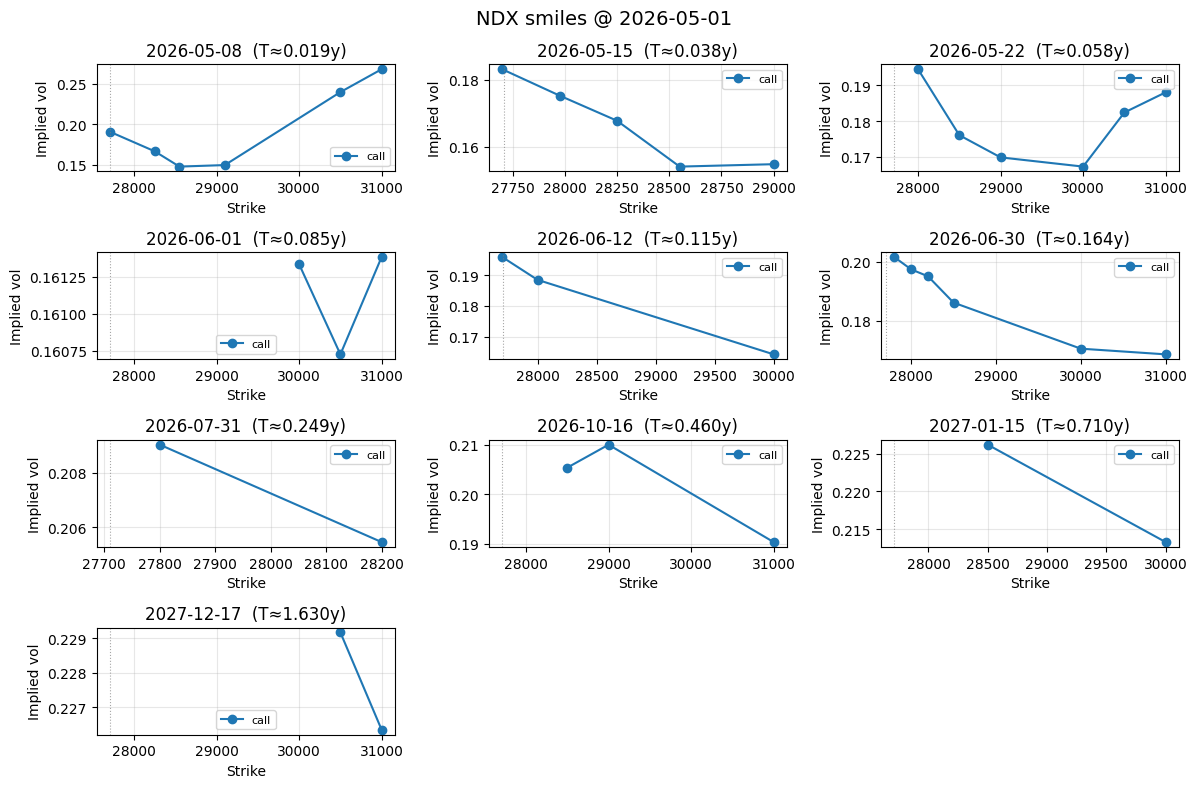

In [12]:
plot_vol_smiles(points, spot=spot, title=f"{UNDERLYING} smiles @ {AS_OF}")
plt.show()

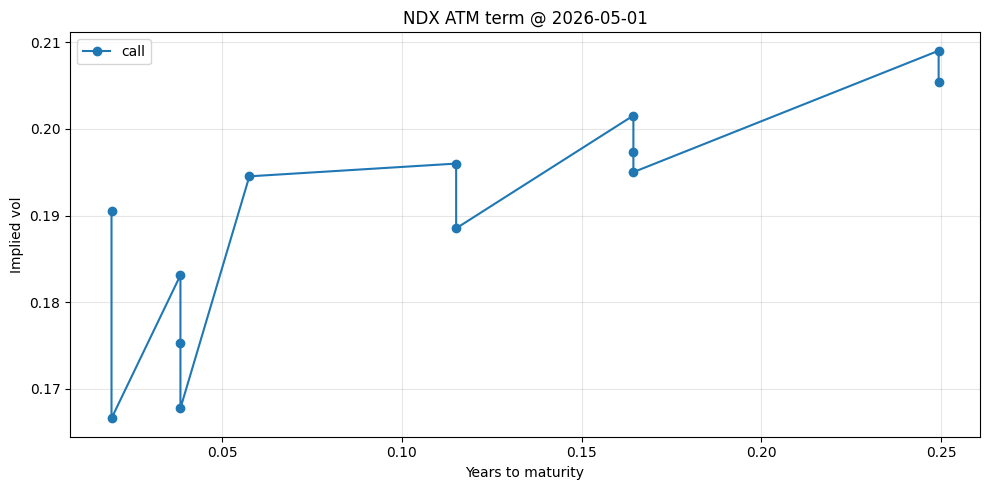

In [13]:
plot_term_structure_atm(points, spot=spot, title=f"{UNDERLYING} ATM term @ {AS_OF}")
plt.show()

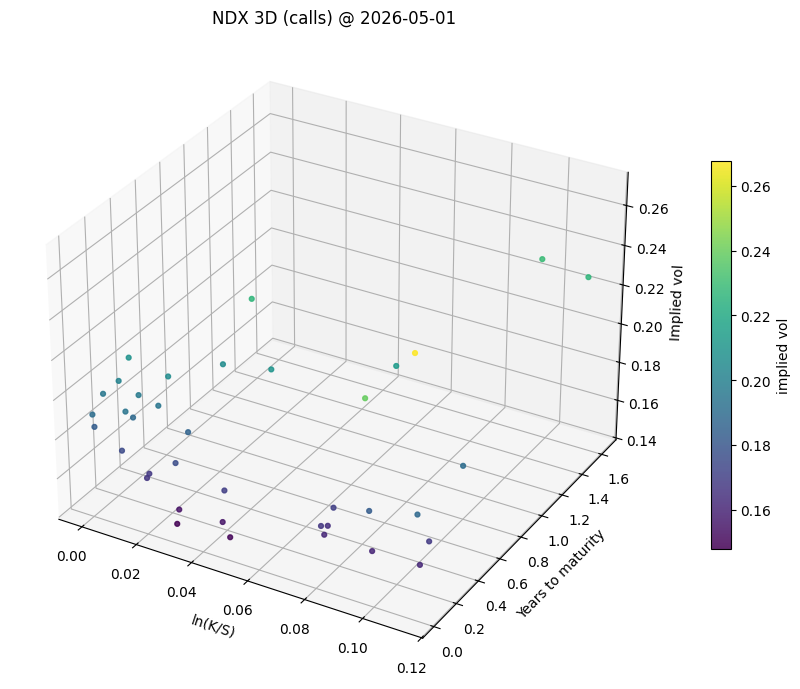

In [14]:
plot_vol_surface_3d(points, spot=spot, contract_type="call", title=f"{UNDERLYING} 3D (calls) @ {AS_OF}")
plt.show()

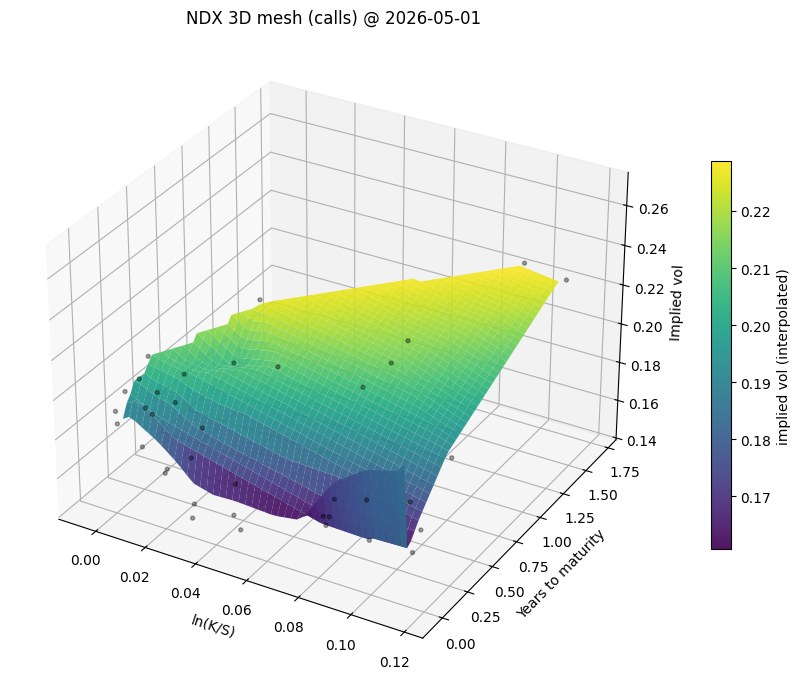

In [15]:
# Interpolated mesh (visualization only — not the production surface used in pricing)
plot_vol_surface_3d_mesh(
    points,
    spot=spot,
    contract_type="call",
    title=f"{UNDERLYING} 3D mesh (calls) @ {AS_OF}",
    grid_resolution=50,
    interp_method="linear",
    show_scatter=True,
)
plt.show()

In [16]:
# Quality breakdown (when QUALITY="all" you can inspect rejects)
points.groupby(["quality", "contract_type"]).size().unstack(fill_value=0)

contract_type,call
quality,
ok,38
